# Analyse des données du baccalauréat en France

Ce notebook analyse les données du baccalauréat en France à partir des résultats par académie.  
Grâce à un EDA (fait sur un notebook dédié), un preprocessing et modélisation de Machine Learning  
pour prédire la mention majoritaire.

## Import + configuation

In [28]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import  VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## Chargement des données déjà nettoyées

In [29]:
path= '../data/clean_dataset.csv'
df = pd.read_csv(path, delimiter=',')

## Construction du dataset de modelisation

Création d'un nouveau dataset (copie du 1er) avec uniquement les colonnes utilisées  
dans notre modèle.

In [30]:
df_ml = df.copy()

column_droped = [ 
    'admis_au_1er_groupe',
    'refuses_au_1er_groupe', 
    'ajournes_passant_les_epreuves_du_rattrapage', 
    'refuses_au_rattrapage',
    'refuses_totaux',
    'admis_au_rattrapage'
]

df_ml = df_ml.drop(columns=column_droped)

Création de colonnes :  
colonne cible avec les mentions majoritaires et mapping pour une meilleur lisibilité 
colonne taux de présence  

In [31]:
column_mention = [
    'mention_tb_avec_les_felicitations',
    'mention_tb_sans_les_felicitations',
    'mention_b',
    'mention_ab', 
    'sans_mention',
]

df_ml['mention_majoritaire'] = df_ml.loc[:,column_mention].idxmax(axis=1)

mapping_mention = {
    'mention_ab': 'AB',
    'sans_mention' : 'sans_mention',
    'mention_b' : 'B',
    'mention_tb_sans_les_felicitations' : 'TB',
    'mention_tb_avec_les_felicitations' : 'TB',
}

df_ml['mention_majoritaire'] = df_ml['mention_majoritaire'].map(mapping_mention)

df_ml['taux_presence'] = df_ml['presents'] / df_ml['inscrits'] 

Distribution de la colonne cible

In [32]:
df_target = df_ml['mention_majoritaire'].value_counts().reset_index().sort_values(by='count')
px.bar(df_target, x='mention_majoritaire', y='count')

## Preprocessing

Séparation de la cible Y des features X

In [33]:
target_name = 'mention_majoritaire'
features = ['session', 'academie', 'sexe', 'statut_du_candidat','serie','taux_presence']

print('Separating labels from features...')
Y = df_ml.loc[:, target_name]
X = df_ml.loc[:, features]
print('...Done.')
print(f'{Y.head(3)}\n')
print(f'{X.head(3)}\n')

print('Dividing into train and test sets...')
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y) 
print('...Done.\n')

Separating labels from features...
...Done.
0    AB
1     B
2     B
Name: mention_majoritaire, dtype: object

   session       academie sexe       statut_du_candidat    serie  \
0     2021  aix-marseille    F  enseignement_a_distance  general   
1     2021         amiens    F  enseignement_a_distance  general   
2     2021       besancon    F  enseignement_a_distance  general   

   taux_presence  
0           0.95  
1           1.00  
2           0.96  

Dividing into train and test sets...
...Done.



Détection des colonnes numériques et catégorielles

In [34]:
numeric_features = []
categorical_features = []
for i,t in X.dtypes.items():
    if ('float' in str(t)) or ('int' in str(t)) :
        numeric_features.append(i)
    else :
        categorical_features.append(i)

print('Found numeric features ', numeric_features)
print('\nFound categorical features ', categorical_features)

Found numeric features  ['session', 'taux_presence']

Found categorical features  ['academie', 'sexe', 'statut_du_candidat', 'serie']


Transformation des colonnes catégorielles et numériques  
Application sur train et test set

In [35]:
numeric_transformer = StandardScaler() 
categorical_transformer = OneHotEncoder(drop='first')  

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Preprocessings on train set
print('Performing preprocessings on train set...')
print(X_train.head(3))
X_train = preprocessor.fit_transform(X_train)
print('...Done.')
print(X_train[0:3])

# Preprocessings on test set
print('\nPerforming preprocessings on test set...')
print(X_test.head(3))
X_test = preprocessor.transform(X_test)  
print('...Done.')
print(X_test[0:3, :])  

Performing preprocessings on train set...
      session  academie sexe statut_du_candidat                serie  \
7322     2025  bordeaux    M         individuel                 st2s   
7491     2025     dijon    M           scolaire                 sthr   
5267     2024  besancon    M           scolaire  pro_production_agri   

      taux_presence  
7322           0.50  
7491           1.00  
5267           0.99  
...Done.
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 18 stored elements and shape (3, 51)>
  Coords	Values
  (0, 0)	1.4059029387284352
  (0, 1)	-1.8844388486024832
  (0, 4)	1.0
  (0, 31)	1.0
  (0, 34)	1.0
  (0, 44)	1.0
  (1, 0)	1.4059029387284352
  (1, 1)	0.4874265952223231
  (1, 8)	1.0
  (1, 31)	1.0
  (1, 35)	1.0
  (1, 47)	1.0
  (2, 0)	0.6935400529975091
  (2, 1)	0.460625855744077
  (2, 3)	1.0
  (2, 31)	1.0
  (2, 35)	1.0
  (2, 38)	1.0

Performing preprocessings on test set...
      session          academie sexe statut_du_candidat     serie  \
6613     202

Encodage de la variable cible

In [36]:
labelencoder = LabelEncoder()

print('Encoding labels on train set...')
print(Y_train.head())
Y_train = labelencoder.fit_transform(Y_train)
print('\n...Done.')
print(Y_train[0:3])

print('\nEncoding labels on test set...')
print(Y_test.head())
Y_test = labelencoder.transform(Y_test)
print('\n...Done.')
print(Y_test[0:3])

Encoding labels on train set...
7322              TB
7491    sans_mention
5267    sans_mention
5607              AB
5448              TB
Name: mention_majoritaire, dtype: object

...Done.
[2 3 3]

Encoding labels on test set...
6613              AB
5566    sans_mention
574     sans_mention
5854    sans_mention
6970              TB
Name: mention_majoritaire, dtype: object

...Done.
[0 3 3]


## Modélisation  

Utilisation de 4 modèles :  
- Logistic Regression puis optimisation par Gridsearch  
- Random Forest Classifier puis optimisation par Gridsearch  
- XGB Classifier puis optimisation par Gridsearch  
- Gadient Boosting Classifier  
- Voting Classifier à partir de 3 modèles :  
Random Forest Classifier  
Logistic Regression  
SVC  

### Modèle : Logistic Regression

In [37]:
# Train model
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

print('Training model...')
lr.fit(X_train, Y_train)
print('...Done.')

# Predictions on training set
print('Predictions on training set...')
Y_train_pred = lr.predict(X_train)
print('...Done.')
print(Y_train_pred[0:5])

# Predictions on test set
print('Predictions on test set...')
Y_test_pred = lr.predict(X_test)
print('...Done.')
print(Y_test_pred[0:5])


#scores
lr_accuracy_train = accuracy_score(Y_train, Y_train_pred)
lr_accuracy_test = accuracy_score(Y_test, Y_test_pred)
lr_f1_train = f1_score(Y_train, Y_train_pred, average='weighted')
lr_f1_test = f1_score(Y_test, Y_test_pred, average='weighted')


# Print scores
print(f'\naccuracy_score on training set : {lr_accuracy_train}') 
print(f'accuracy_score on test set : {lr_accuracy_test}')
print(f'\nf1_score weighted on training set : {lr_f1_train}')
print(f'f1_score weighted on test set : {lr_f1_test}')

Training model...
...Done.
Predictions on training set...
...Done.
[2 0 3 0 2]
Predictions on test set...
...Done.
[3 3 3 2 2]

accuracy_score on training set : 0.5746207796444299
accuracy_score on test set : 0.5518590998043053

f1_score weighted on training set : 0.5971200287669097
f1_score weighted on test set : 0.5765187819725427


#### Optimisation par Gridsearch

In [38]:
# Perform grid search
print('Grid search...')
# Grid of values to be tested
params = {
    'C' : [0.01, 0.1, 1, 10, 100],
    'max_iter' :[200,500,1000]
}
lgridsearch = GridSearchCV(lr, param_grid=params, cv=5, scoring='f1_weighted')  
lgridsearch.fit(X_train, Y_train)
print('...Done.')
print(f'Best hyperparameters : {lgridsearch.best_params_}')

#Predict with gridsearch params
best_model = lgridsearch.best_estimator_

Y_train_pred = best_model.predict(X_train)
Y_test_pred = best_model.predict(X_test)

#scores
glr_accuracy_train = accuracy_score(Y_train, Y_train_pred)
glr_accuracy_test = accuracy_score(Y_test, Y_test_pred)
glr_f1_train = f1_score(Y_train, Y_train_pred, average='weighted')
glr_f1_test = f1_score(Y_test, Y_test_pred, average='weighted')

#Print scores
print(f'\naccuracy_score on training set : {glr_accuracy_train}') 
print(f'accuracy_score on test set : {glr_accuracy_test}')

print(f'\nf1_score weighted on training set : {glr_f1_train}')
print(f'f1_score weighted on test set : {glr_f1_test}')

Grid search...
...Done.
Best hyperparameters : {'C': 100, 'max_iter': 200}

accuracy_score on training set : 0.577230468112869
accuracy_score on test set : 0.5505544683626875

f1_score weighted on training set : 0.5996944539657135
f1_score weighted on test set : 0.5750869752765484


### Modèle : Random Forest Classifier

In [39]:
# Train model
rc = RandomForestClassifier(n_jobs=-1, random_state=42)

print('Training model...')
rc.fit(X_train, Y_train)
print('...Done.')

# Predictions on training and test set
print('Predictions on training set...')
Y_train_pred = rc.predict(X_train)
print('...Done.')

print('Predictions on test set...')
Y_test_pred = rc.predict(X_test)
print('...Done.')

rc_accuracy_train = accuracy_score(Y_train, Y_train_pred)
rc_accuracy_test = accuracy_score(Y_test, Y_test_pred)
rc_f1_train = f1_score(Y_train, Y_train_pred, average='weighted')
rc_f1_test = f1_score(Y_test, Y_test_pred, average='weighted')

# Print scores
print(f'\naccuracy_score on training set : {rc_accuracy_train}') 
print(f'accuracy_score on test set : {rc_accuracy_test}')

print(f'\nf1_score weighted on training set : {rc_f1_train}')
print(f'f1_score weighted on test set : {rc_f1_test}')

Training model...
...Done.
Predictions on training set...
...Done.
Predictions on test set...
...Done.

accuracy_score on training set : 1.0
accuracy_score on test set : 0.6777560339204175

f1_score weighted on training set : 1.0
f1_score weighted on test set : 0.6676004896959368


#### Optimisation par Gridsearch

In [40]:
# Perform grid search
print('Grid search...')
# Grid of values to be tested
params = {
    'n_estimators': [50, 80, 120, 150],
    'max_depth': [6, 8, 10, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rgridsearch = GridSearchCV(rc, param_grid=params, cv=3, scoring='f1_weighted')  
rgridsearch.fit(X_train, Y_train)
print('...Done.')
print(f'Best hyperparameters : {rgridsearch.best_params_}')

#Predict with gridsearch params
best_model = rgridsearch.best_estimator_

Y_train_pred = best_model.predict(X_train)
Y_test_pred = best_model.predict(X_test)

#scores
grc_accuracy_train = accuracy_score(Y_train, Y_train_pred)
grc_accuracy_test = accuracy_score(Y_test, Y_test_pred)
grc_f1_train = f1_score(Y_train, Y_train_pred, average='weighted')
grc_f1_test = f1_score(Y_test, Y_test_pred, average='weighted')

#  Print scores
print(f'\naccuracy_score on training set : {grc_accuracy_train}') 
print(f'accuracy_score on test set : {grc_accuracy_test}')
print(f'\nf1_score weighted on training set : {grc_f1_train}')
print(f'f1_score weighted on test set : {grc_f1_test}')

Grid search...
...Done.
Best hyperparameters : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 150}

accuracy_score on training set : 0.8134072745066058
accuracy_score on test set : 0.6908023483365949

f1_score weighted on training set : 0.8043944746066947
f1_score weighted on test set : 0.6737032011887816


### Modèle : XGB Classifier

In [41]:
# Train model
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.5,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1
)

print('Training model...')
xgb.fit(X_train, Y_train)
print('...Done.')

# Predictions on training and test set
print('Predictions on training set...')
Y_train_pred = xgb.predict(X_train)
print('...Done.')

print('Predictions on test set...')
Y_test_pred = xgb.predict(X_test)
print('...Done.')

#scores
xgb_accuracy_train = accuracy_score(Y_train, Y_train_pred)
xgb_accuracy_test = accuracy_score(Y_test, Y_test_pred)
xgb_f1_train = f1_score(Y_train, Y_train_pred, average='weighted')
xgb_f1_test = f1_score(Y_test, Y_test_pred, average='weighted')

# Print scores
print(f'\naccuracy_score on training set : {xgb_accuracy_train}') 
print(f'accuracy_score on test set : {xgb_accuracy_test}')
print(f'\nf1_score weighted on training set : {xgb_f1_train}')
print(f'f1_score weighted on test set : {xgb_f1_test}')

Training model...
...Done.
Predictions on training set...
...Done.
Predictions on test set...
...Done.

accuracy_score on training set : 0.9714565323764476
accuracy_score on test set : 0.6744944553163731

f1_score weighted on training set : 0.9713618659629122
f1_score weighted on test set : 0.6674964458964091


#### Optimisation par Gridsearch

In [42]:
# Perform grid search
print('Grid search...')
# Grid of values to be tested
params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [1, 3, 5],
    'colsample_bytree': [0.8, 1.0],
    'subsample': [0.8, 1.0]
}
xgbgridsearch = GridSearchCV(xgb, param_grid=params, cv=5, scoring='f1_weighted', n_jobs=-1 )  
xgbgridsearch.fit(X_train, Y_train)
print('...Done.')
print(f'Best hyperparameters : {xgbgridsearch.best_params_}')

#Predict with gridsearch params
best_model = xgbgridsearch.best_estimator_

Y_train_pred = best_model.predict(X_train)
Y_test_pred = best_model.predict(X_test)

#scores
gxgb_accuracy_train = accuracy_score(Y_train, Y_train_pred)
gxgb_accuracy_test = accuracy_score(Y_test, Y_test_pred)
gxgb_f1_train = f1_score(Y_train, Y_train_pred, average='weighted')
gxgb_f1_test = f1_score(Y_test, Y_test_pred, average='weighted')

#  Print scores
print(f'\naccuracy_score on training set : {gxgb_accuracy_train}') 
print(f'accuracy_score on test set : {gxgb_accuracy_test}')
print(f'\nf1_score on training set : {gxgb_f1_train}')
print(f'f1_score on test set : {gxgb_f1_test}')

Grid search...
...Done.
Best hyperparameters : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150, 'subsample': 0.8}

accuracy_score on training set : 0.7802968520632849
accuracy_score on test set : 0.6894977168949772

f1_score on training set : 0.7687182393771421
f1_score on test set : 0.6728727668232816


### Modèle : Gradient Boosting Classifier

In [43]:
# Train model
gbc = GradientBoostingClassifier(random_state=42)

print('Training model...')
gbc.fit(X_train, Y_train)
print('...Done.')

# Predictions on training and test set
print('Predictions on training set...')
Y_train_pred = gbc.predict(X_train)
print('...Done.')

print('Predictions on test set...')
Y_test_pred = gbc.predict(X_test)
print('...Done.')

#scores
gbc_accuracy_train = accuracy_score(Y_train, Y_train_pred)
gbc_accuracy_test = accuracy_score(Y_test, Y_test_pred)
gbc_f1_train = f1_score(Y_train, Y_train_pred, average='weighted')
gbc_f1_test = f1_score(Y_test, Y_test_pred, average='weighted')

# Print scores
print(f'\naccuracy_score on training set : {gbc_accuracy_train}') 
print(f'accuracy_score on test set : {gbc_accuracy_test}')
print(f'\nf1_score weighted on training set : {gbc_f1_train}')
print(f'f1_score weighted on test set : {gbc_f1_test}')

Training model...
...Done.
Predictions on training set...
...Done.
Predictions on test set...
...Done.

accuracy_score on training set : 0.7230468112869026
accuracy_score on test set : 0.6797129810828441

f1_score weighted on training set : 0.7009639922444861
f1_score weighted on test set : 0.6507805431376068


#### Optimisation par Gridsearch

In [44]:
# Perform grid search
print('Grid search...')
# Grid of values to be tested
params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [1, 3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3],
    'subsample': [0.8, 1.0]
}
ggridsearch = GridSearchCV(gbc, param_grid=params, cv=5, scoring='f1_weighted', n_jobs=-1 )  
ggridsearch.fit(X_train, Y_train)
print('...Done.')
print(f'Best hyperparameters : {ggridsearch.best_params_}')

#Predict with gridsearch params
best_model = ggridsearch.best_estimator_

Y_train_pred = best_model.predict(X_train)
Y_test_pred = best_model.predict(X_test)

#scores
ggbc_accuracy_train = accuracy_score(Y_train, Y_train_pred)
ggbc_accuracy_test = accuracy_score(Y_test, Y_test_pred)
ggbc_f1_train = f1_score(Y_train, Y_train_pred, average='weighted')
ggbc_f1_test = f1_score(Y_test, Y_test_pred, average='weighted')

#  Print scores
print(f'\naccuracy_score on training set : {ggbc_accuracy_train}') 
print(f'accuracy_score on test set : {ggbc_accuracy_test}')
print(f'\nf1_score on training set : {ggbc_f1_train}')
print(f'f1_score on test set : {ggbc_f1_test}')

Grid search...
...Done.
Best hyperparameters : {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 0.8}

accuracy_score on training set : 0.8015005708693524
accuracy_score on test set : 0.6914546640574037

f1_score on training set : 0.792730669103809
f1_score on test set : 0.6757460888844447


### Modèle : Voting Classifier

In [45]:
# Train model
rc = RandomForestClassifier(n_jobs=-1, random_state=42)
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
svw = SVC(probability=True, random_state=42)

model = VotingClassifier(
    estimators=[
        ('rr', rc),
        ('lr', lr),
        ('swm', svw)
    ],
    voting='soft', 
    n_jobs=-1
)

print('Training model...')
model.fit(X_train, Y_train)
print('...Done.')

# Predictions on training and test set
print('Predictions on training set...')
Y_train_pred = model.predict(X_train)
print('...Done.')

print('Predictions on test set...')
Y_test_pred = model.predict(X_test)
print('...Done.')

#scores
voting_c_accuracy_train = accuracy_score(Y_train, Y_train_pred)
voting_c_accuracy_test = accuracy_score(Y_test, Y_test_pred)
voting_c_f1_train = f1_score(Y_train, Y_train_pred, average='weighted')
voting_c_f1_test = f1_score(Y_test, Y_test_pred, average='weighted')

# Print scores
print(f'\naccuracy_score on training set : {voting_c_accuracy_train}') 
print(f'accuracy_score on test set : {voting_c_accuracy_test}')
print(f'\nf1_score on training set : {voting_c_f1_train}')
print(f'f1_score on test set : {voting_c_f1_test}')

Training model...
...Done.
Predictions on training set...
...Done.
Predictions on test set...
...Done.

accuracy_score on training set : 0.8755504811613114
accuracy_score on test set : 0.6810176125244618

f1_score on training set : 0.8729682664699424
f1_score on test set : 0.6738039337815822


## Comparaison des résultats

In [46]:
model_name = [
    'accuracy on train',
    'accuracy on test',
    'f1_score on train',
    'f1_score on test',

]

logsitic_regression = [
    lr_accuracy_train,
    lr_accuracy_test,
    lr_f1_train,
    lr_f1_test
]

gridsearch_logistic_regression = [
    glr_accuracy_train,
    glr_accuracy_test,
    glr_f1_train,
    glr_f1_test
]

random_forest_classifier = [
    rc_accuracy_train,
    rc_accuracy_test,
    rc_f1_train,
    rc_f1_test
]

gridsearch_random_forest_classifier = [
    grc_accuracy_train,
    grc_accuracy_test,
    grc_f1_train,
    grc_f1_test
]

xgboost_classifier = [
    xgb_accuracy_train,
    xgb_accuracy_test,
    xgb_f1_train,
    xgb_f1_test        
]

gridsearch_xgboost_classifier = [
    gxgb_accuracy_train,
    gxgb_accuracy_test,
    gxgb_f1_train,
    gxgb_f1_test        
]

gradient_boost_classifier = [
    gbc_accuracy_train,
    gbc_accuracy_test,
    gbc_f1_train,
    gbc_f1_test
]

gridsearch_gradient_boost_classifier = [
    ggbc_accuracy_train,
    ggbc_accuracy_test,
    ggbc_f1_train,
    ggbc_f1_test
]

voting_classifier = [
    voting_c_accuracy_train,
    voting_c_accuracy_test,
    voting_c_f1_train,
    voting_c_f1_test
]

df_score = pd.DataFrame(
    {
        'model_name' : model_name, 
        'logsitic_regression' : logsitic_regression, 
        'gridsearch_logistic_regression' : gridsearch_logistic_regression, 
        'random_forest_classifier' : random_forest_classifier, 
        'gridsearch_random_forest_classifier' : gridsearch_random_forest_classifier,
        'xgboost_classifier' : xgboost_classifier,
        'gridsearch_xgboost_classifier' : gridsearch_xgboost_classifier,
        'gradient_boost_classifier' : gradient_boost_classifier,
        'gridsearch_gradient_boost_classifier' : gridsearch_gradient_boost_classifier,
        'voting_classifier' : voting_classifier
    }
)

df_score = df_score.set_index('model_name')
display(df_score)

,logsitic_regression,gridsearch_logistic_regression,random_forest_classifier,gridsearch_random_forest_classifier,xgboost_classifier,gridsearch_xgboost_classifier,gradient_boost_classifier,gridsearch_gradient_boost_classifier,voting_classifier
model_name,,,,,,,,,
accuracy on train,0.57,0.58,1.00,0.81,0.97,0.78,0.72,0.80,0.88
accuracy on test,0.55,0.55,0.68,0.69,0.67,0.69,0.68,0.69,0.68
f1_score on train,0.60,0.60,1.00,0.80,0.97,0.77,0.70,0.79,0.87
f1_score on test,0.58,0.58,0.67,0.67,0.67,0.67,0.65,0.68,0.67


D'après nos résultats, Gradient boost classifier est le meilleur model.   
Meilleur accuracy et f1 score avec un overfit léger !

## Matrice de confusion du meilleur modèle

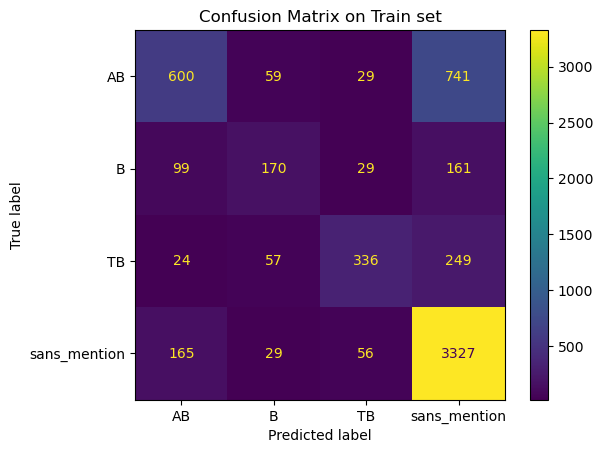

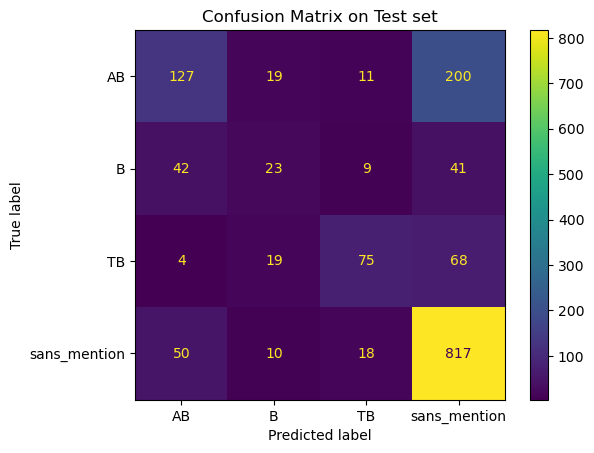

In [53]:
labels = labelencoder.classes_

# Visualize confusion matrices
_, ax = plt.subplots() 
ax.set(title='Confusion Matrix on Train set')  
ConfusionMatrixDisplay.from_estimator(gbc, X_train, Y_train, ax=ax, display_labels=labels)  
plt.show()

_, ax = plt.subplots() 
ax.set(title='Confusion Matrix on Test set')  
ConfusionMatrixDisplay.from_estimator(gbc, X_test, Y_test, ax=ax, display_labels=labels) 
plt.show()

## Interprétation : Feature importance 

In [48]:
#column names from preprocessor
column_names = preprocessor.get_feature_names_out()

Nettoyage du nom des colonnes pour une meilleur lisibilité.

In [49]:
column_names = pd.Series(column_names).str.replace('num__','').str.replace('cat__','')

In [50]:
# Create a pandas DataFrame
feature_importance = pd.DataFrame(
    index=column_names,
    data=gbc.feature_importances_,
    columns=["feature_importances"],
)
feature_importance = feature_importance.sort_values(by="feature_importances")

Mise en forme graphique des coefficients

In [51]:
fig_feature = px.bar(feature_importance, orientation="h")
fig_feature.update_layout(showlegend=False, margin={"l": 120})
fig_feature.update_layout(autosize=False, width=1200, height=600)

fig_feature.show()

Top 5 des coefficients

In [52]:
feature_importance.sort_values(by="feature_importances", ascending=False).head(5)

,feature_importances
taux_presence,0.23
statut_du_candidat_individuel,0.11
serie_s2tmd,0.08
serie_std2a,0.08
statut_du_candidat_scolaire,0.07


## Conclusion  

Variables clés : taux de présence, statut du candidat et série.   
Biais potentiels : données agrégées, pas de variables individuelles.  
Le meilleur modèles ML montre des performances plus élevés pour la prédictions de la  
mention majoritaire par rapport aux 2 autres approches (accuracy et f1 score environ 0.7).    
Même Limites : absence de données individuelles, agrégation par groupes.  
Même améliorations possibles : données plus précises non agrégées, création de nouvelles features.